In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pairs_df = pd.read_csv('../data/processed/pair_risk_scores_day4.csv')
print("Shape:", pairs_df.shape)
print(pairs_df.head())

Shape: (6336, 9)
  airport_A airport_B  month  risk_A  risk_B  pair_risk_score  season  \
0       ATL       AUS      1  0.3501  0.2600           0.3017  Winter   
1       ATL       BNA      1  0.3501  0.6157           0.4643  Winter   
2       ATL       BOS      1  0.3501  0.1598           0.2365  Winter   
3       ATL       CLT      1  0.3501  0.2025           0.2663  Winter   
4       ATL       DCA      1  0.3501  0.3123           0.3306  Winter   

   buffer_risk  SHIELD_pair_score  
0       0.2857             0.3224  
1       0.3571             0.5522  
2       0.4821             0.3450  
3       0.4107             0.3440  
4       0.4464             0.4387  


In [2]:
# FAA Part 117 Hard Limits — these are LAW
FAA_MAX_DUTY_HOURS       = 14.0   # max duty period
FAA_MAX_FLIGHT_HOURS_DAY = 8.0    # max flight time single pilot
FAA_MIN_REST_HOURS       = 10.0   # min rest before duty
FAA_MAX_WEEKLY_HOURS     = 30.0   # max 7-day flight hours

# Operational assumptions
DFW_TURNAROUND_HOURS = 1.0        # 1 hour standard DFW turn

# Average flight times (hours) — same as Day 4
FLIGHT_TIMES = {
    'LAX': 3.5, 'LAS': 2.75, 'ATL': 2.25, 'ORD': 2.5,  'DEN': 2.0,
    'PHX': 2.25,'MIA': 2.75, 'JFK': 3.25, 'LGA': 3.25, 'CLT': 2.5,
    'MCO': 2.5, 'SEA': 3.75, 'BOS': 3.5,  'SFO': 3.75, 'IAH': 1.25,
    'HOU': 1.25,'SAN': 3.25, 'PHL': 3.25, 'DCA': 3.0,  'MSP': 2.25,
    'DTW': 2.5, 'MDW': 2.25, 'SLC': 2.5,  'PDX': 3.5,  'AUS': 0.75,
    'SAT': 1.0, 'ELP': 1.5,  'OKC': 1.25, 'TUL': 1.25, 'MSY': 1.5,
    'MEM': 1.5, 'BNA': 1.75, 'RDU': 2.75, 'TPA': 2.5,  'FLL': 2.75
}
DEFAULT_FLIGHT_TIME = 2.5

In [3]:
risk_df = pd.read_csv('../data/processed/airport_risk_scores.csv')

# Get avg weather delay per airport per month (convert to hours)
airport_summary = pd.read_csv('../data/processed/airport_month_summary_day2.csv')
avg_delay_lookup = (
    airport_summary[['ORIGIN', 'MONTH', 'avg_weather_delay']]
    .copy()
)
avg_delay_lookup['avg_delay_hours'] = avg_delay_lookup['avg_weather_delay'] / 60
avg_delay_lookup = avg_delay_lookup.set_index(['ORIGIN', 'MONTH'])

print("Avg delay lookup shape:", avg_delay_lookup.shape)
print(avg_delay_lookup.head())

Avg delay lookup shape: (396, 2)
              avg_weather_delay  avg_delay_hours
ORIGIN MONTH                                    
ATL    1               2.992844         0.049881
       2               0.151970         0.002533
       3               0.970443         0.016174
       4               1.671164         0.027853
       5               1.630990         0.027183


In [4]:
def compute_duty_metrics(row):
    a = row['airport_A']
    b = row['airport_B']
    month = int(row['month'])

    # Flight times
    ft_a = FLIGHT_TIMES.get(a, DEFAULT_FLIGHT_TIME)
    ft_b = FLIGHT_TIMES.get(b, DEFAULT_FLIGHT_TIME)

    # Get predicted weather delay for airport A this month
    try:
        predicted_delay = avg_delay_lookup.loc[(a, month), 'avg_delay_hours']
    except KeyError:
        predicted_delay = 0.25  # default 15 min if not found

    # Total sequence time including predicted delay
    total_time = ft_a + predicted_delay + DFW_TURNAROUND_HOURS + ft_b

    # Total pure flight time (A + B legs)
    total_flight_time = ft_a + ft_b

    # Duty violation: does sequence exceed 14hr max duty period?
    duty_violation = 1 if total_time > FAA_MAX_DUTY_HOURS else 0

    # Flight hour violation: do flight hours exceed 8hr daily max?
    flight_hour_violation = 1 if total_flight_time > FAA_MAX_FLIGHT_HOURS_DAY else 0

    # Duty buffer remaining (hours) — negative = violation
    duty_buffer = FAA_MAX_DUTY_HOURS - total_time

    # Duty risk score: 0=very safe, 1=violation
    duty_risk = max(0, 1 - (duty_buffer / FAA_MAX_DUTY_HOURS))

    return pd.Series({
        'ft_a_hours':            round(ft_a, 2),
        'ft_b_hours':            round(ft_b, 2),
        'predicted_delay_hours': round(predicted_delay, 2),
        'total_sequence_hours':  round(total_time, 2),
        'total_flight_hours':    round(total_flight_time, 2),
        'duty_buffer_hours':     round(duty_buffer, 2),
        'duty_violation_flag':   duty_violation,
        'flight_hr_violation':   flight_hour_violation,
        'duty_risk_score':       round(duty_risk, 4)
    })

print("Computing duty metrics for all pairs...")
duty_results = pairs_df.apply(compute_duty_metrics, axis=1)
pairs_final = pd.concat([pairs_df, duty_results], axis=1)
print("Done!")
print(pairs_final.shape)
print(pairs_final[['airport_A','airport_B','month','total_sequence_hours',
                   'duty_buffer_hours','duty_violation_flag','duty_risk_score']].head(10))

Computing duty metrics for all pairs...
Done!
(6336, 18)
  airport_A airport_B  month  total_sequence_hours  duty_buffer_hours  \
0       ATL       AUS      1                  4.05               9.95   
1       ATL       BNA      1                  5.05               8.95   
2       ATL       BOS      1                  6.80               7.20   
3       ATL       CLT      1                  5.80               8.20   
4       ATL       DCA      1                  6.30               7.70   
5       ATL       DEN      1                  5.30               8.70   
6       ATL       DTW      1                  5.80               8.20   
7       ATL       ELP      1                  4.80               9.20   
8       ATL       FLL      1                  6.05               7.95   
9       ATL       IAH      1                  4.55               9.45   

   duty_violation_flag  duty_risk_score  
0                  0.0           0.2893  
1                  0.0           0.3607  
2            

In [5]:
pairs_final['SHIELD_final_score'] = (
    0.50 * pairs_final['SHIELD_pair_score'] +   # Layer 2: Pair risk
    0.30 * pairs_final['duty_risk_score']    +   # Layer 3: Pilot duty risk
    0.20 * pairs_final['buffer_risk']            # DFW buffer tightness
)

# Normalize to 0–1
mn = pairs_final['SHIELD_final_score'].min()
mx = pairs_final['SHIELD_final_score'].max()
pairs_final['SHIELD_final_score'] = ((pairs_final['SHIELD_final_score'] - mn) / (mx - mn)).round(4)

print("Final SHIELD score range:",
      pairs_final['SHIELD_final_score'].min(), "to",
      pairs_final['SHIELD_final_score'].max())

Final SHIELD score range: 0.0 to 1.0


In [6]:
violations = pairs_final[pairs_final['duty_violation_flag'] == 1]
flight_violations = pairs_final[pairs_final['flight_hr_violation'] == 1]

print(f"Sequences with DUTY PERIOD violations (>14hrs): {len(violations):,}")
print(f"Sequences with FLIGHT HOUR violations (>8hrs):  {len(flight_violations):,}")
print(f"\nExample duty violations:")
print(violations[['airport_A','airport_B','month','total_sequence_hours',
                  'duty_buffer_hours']].head(10).to_string(index=False))

Sequences with DUTY PERIOD violations (>14hrs): 0
Sequences with FLIGHT HOUR violations (>8hrs):  0

Example duty violations:
Empty DataFrame
Columns: [airport_A, airport_B, month, total_sequence_hours, duty_buffer_hours]
Index: []


In [7]:
final_top = (
    pairs_final.groupby(['airport_A','airport_B'])
    .agg(
        avg_SHIELD_final   =('SHIELD_final_score', 'mean'),
        avg_pair_risk      =('SHIELD_pair_score',  'mean'),
        avg_duty_risk      =('duty_risk_score',     'mean'),
        duty_violations    =('duty_violation_flag', 'sum'),
        worst_month        =('SHIELD_final_score',  'idxmax')
    )
    .reset_index()
    .sort_values('avg_SHIELD_final', ascending=False)
)

print("\n=== FINAL TOP 20 FORBIDDEN PAIRS (ALL 3 LAYERS) ===")
print(final_top.head(20)[['airport_A','airport_B','avg_SHIELD_final',
                           'avg_pair_risk','avg_duty_risk',
                           'duty_violations']].to_string(index=False))


=== FINAL TOP 20 FORBIDDEN PAIRS (ALL 3 LAYERS) ===
airport_A airport_B  avg_SHIELD_final  avg_pair_risk  avg_duty_risk  duty_violations
      SEA       SFO          0.632525       0.279583       0.607592              0.0
      PDX       SFO          0.623317       0.287133       0.590392              0.0
      SAN       SFO          0.623225       0.304217       0.573725              0.0
      LGA       SFO          0.619542       0.300267       0.573692              0.0
      PDX       SEA          0.612083       0.275075       0.590392              0.0
      LGA       SEA          0.612033       0.292208       0.573692              0.0
      LGA       SAN          0.610100       0.325850       0.537967              0.0
      SAN       SEA          0.609883       0.289892       0.573725              0.0
      PDX       SAN          0.604292       0.302417       0.554675              0.0
      LGA       PDX          0.603517       0.300892       0.555808              0.0
      LAX   

In [8]:
pairs_final.to_csv('../data/processed/pairs_final_with_duty.csv', index=False)
final_top.to_csv('../data/processed/top_forbidden_pairs_FINAL.csv', index=False)
print("✅ Final outputs saved!")

✅ Final outputs saved!


FileNotFoundError: [Errno 2] No such file or directory: '../report/duty_risk_chart.png'

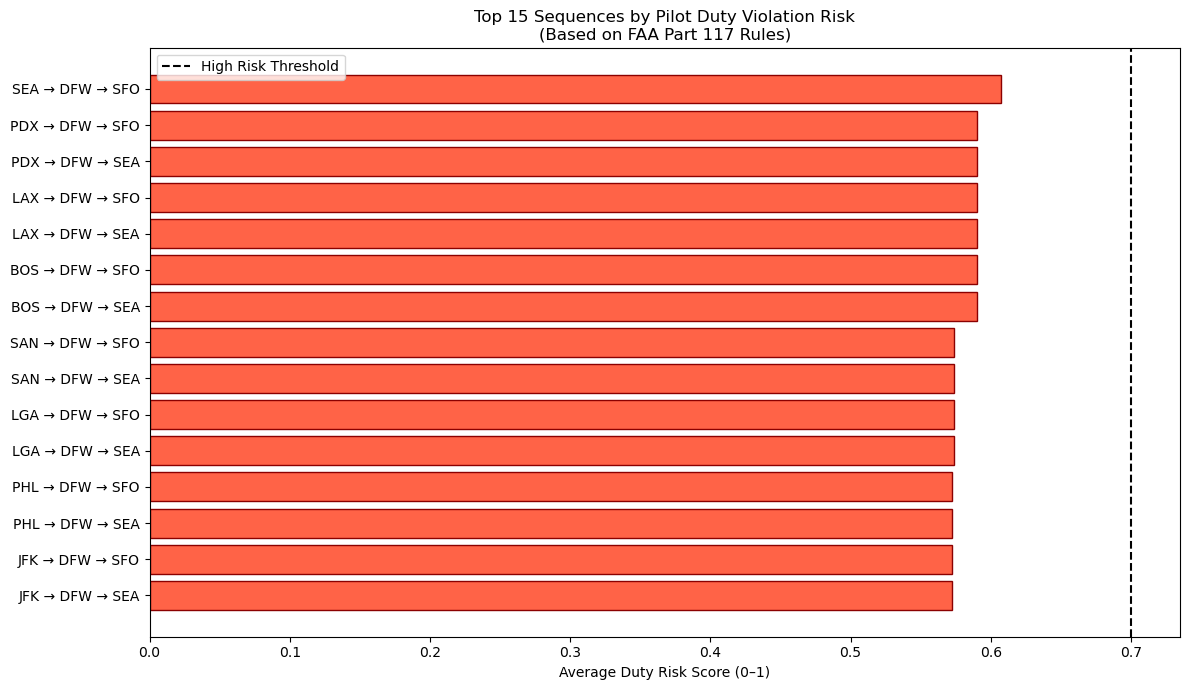

In [9]:
# Show top 15 pairs by duty risk score
top_duty = final_top.nlargest(15, 'avg_duty_risk').copy()
top_duty['pair_label'] = top_duty['airport_A'] + ' → DFW → ' + top_duty['airport_B']

plt.figure(figsize=(12, 7))
plt.barh(top_duty['pair_label'], top_duty['avg_duty_risk'],
         color='tomato', edgecolor='darkred')
plt.axvline(x=0.7, color='black', linestyle='--', label='High Risk Threshold')
plt.xlabel('Average Duty Risk Score (0–1)')
plt.title('Top 15 Sequences by Pilot Duty Violation Risk\n(Based on FAA Part 117 Rules)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../report/duty_risk_chart.png', dpi=200)
plt.show()
print("✅ Duty risk chart saved!")

FileNotFoundError: [Errno 2] No such file or directory: '../report/shield_score_comparison.png'

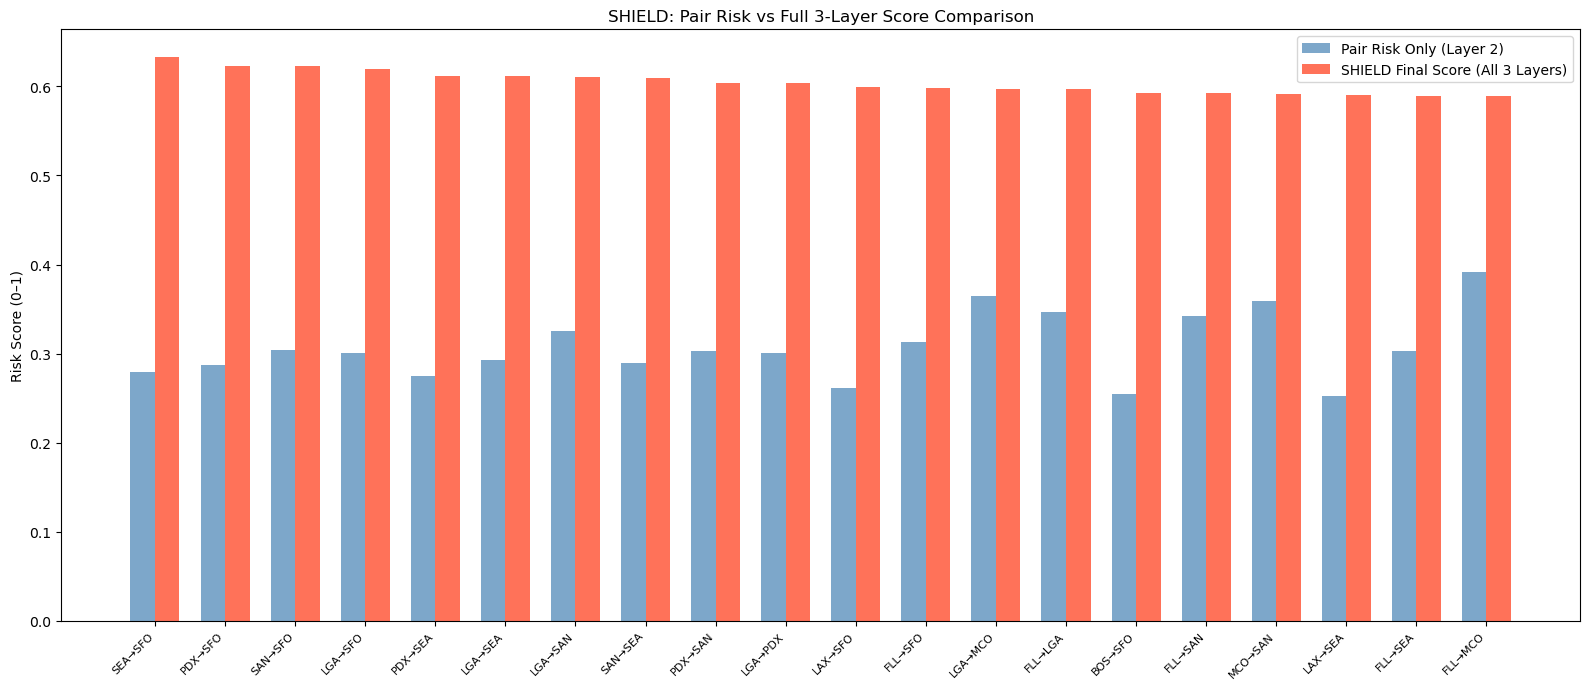

In [10]:
# Compare old pair score vs new final score for top 20
top20_compare = final_top.head(20).copy()
top20_compare['pair_label'] = top20_compare['airport_A'] + '→' + top20_compare['airport_B']

x = range(len(top20_compare))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar([i - width/2 for i in x], top20_compare['avg_pair_risk'],
               width, label='Pair Risk Only (Layer 2)', color='steelblue', alpha=0.7)
bars2 = ax.bar([i + width/2 for i in x], top20_compare['avg_SHIELD_final'],
               width, label='SHIELD Final Score (All 3 Layers)', color='tomato', alpha=0.9)

ax.set_xticks(list(x))
ax.set_xticklabels(top20_compare['pair_label'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Risk Score (0–1)')
ax.set_title('SHIELD: Pair Risk vs Full 3-Layer Score Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../report/shield_score_comparison.png', dpi=200)
plt.show()